In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi oku
df = pd.read_csv("HeartDiseaseTrain-Test.csv")

# İlk 5 satıra bak
print(df.head())
print("\nBoyut:", df.shape)

   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

In [12]:
print("Genel Bilgi:")
print(df.info())

print("\nEksik değer var mı?")
print(df.isnull().sum())

print("\nHedef değişken dağılımı:")
print(df["target"].value_counts())

Genel Bilgi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025

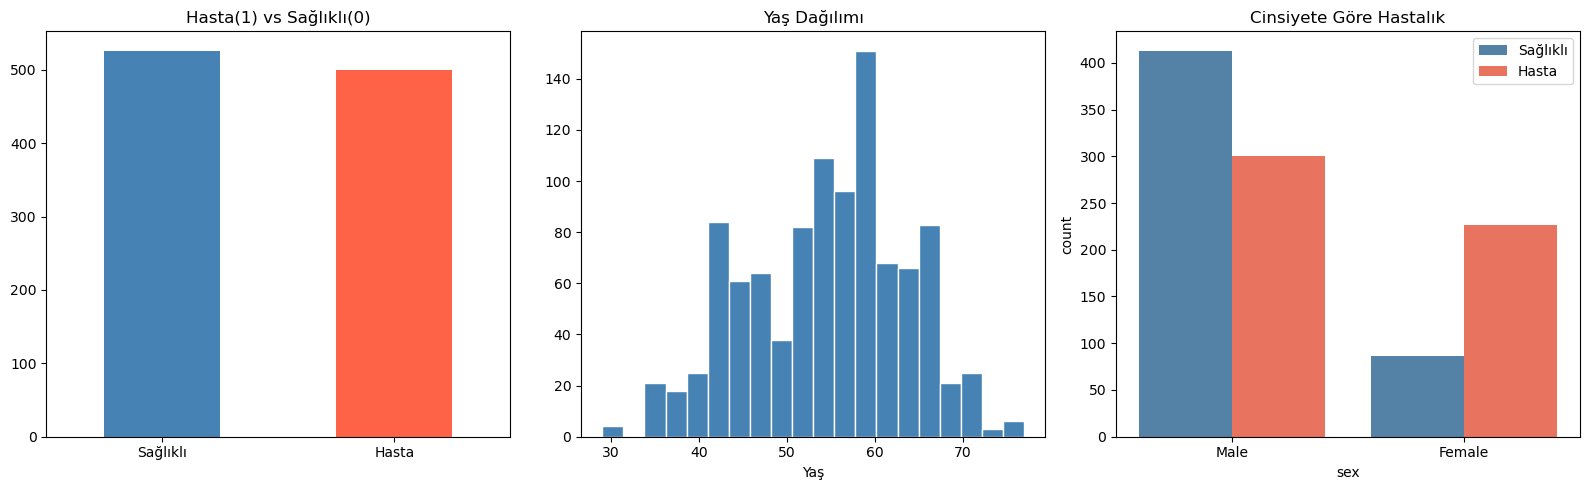

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hasta / Sağlıklı dağılımı
df["target"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Hasta(1) vs Sağlıklı(0)")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["Sağlıklı", "Hasta"], rotation=0)

# Yaş dağılımı
axes[1].hist(df["age"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Yaş Dağılımı")
axes[1].set_xlabel("Yaş")

# Cinsiyete göre hastalık
sns.countplot(data=df, x="sex", hue="target", ax=axes[2], palette=["steelblue", "tomato"])
axes[2].set_title("Cinsiyete Göre Hastalık")
axes[2].legend(["Sağlıklı", "Hasta"])

plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Metin kolonları bul ve sayıya çevir
metin_kolonlar = df.select_dtypes(include="object").columns
print("Çevirilecek kolonlar:", list(metin_kolonlar))

for kolon in metin_kolonlar:
    df[kolon] = le.fit_transform(df[kolon])

print("\nDönüşüm tamamlandı!")
print(df.head())


Çevirilecek kolonlar: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Dönüşüm tamamlandı!
   age  sex  chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    1                3                     125          212   
1   53    1                3                     140          203   
2   70    1                3                     145          174   
3   61    1                3                     148          203   
4   62    0                3                     138          294   

   fasting_blood_sugar  rest_ecg  Max_heart_rate  exercise_induced_angina  \
0                    1         2             168                        0   
1                    0         1             155                        1   
2                    1         2             125                        1   
3                    1         2             161                        0   
4          

In [15]:
from sklearn.model_selection import train_test_split

# X = özellikler, y = tahmin edeceğimiz şey
X = df.drop("target", axis=1)
y = df["target"]

# %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (820, 13)
Test seti: (205, 13)


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Modeli oluştur
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli eğit
model.fit(X_train, y_train)

# Test seti üzerinde tahmin yap
y_pred = model.predict(X_test)

print("Model eğitimi tamamlandı!")
print("İlk 10 tahmin:", y_pred[:10])
print("Gerçek değerler:", y_test.values[:10])

Model eğitimi tamamlandı!
İlk 10 tahmin: [1 1 0 1 0 1 0 0 1 0]
Gerçek değerler: [1 1 0 1 0 1 0 0 1 0]


Model Doğruluğu: %98.54

Detaylı Rapor:
              precision    recall  f1-score   support

    Sağlıklı       0.97      1.00      0.99       102
       Hasta       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



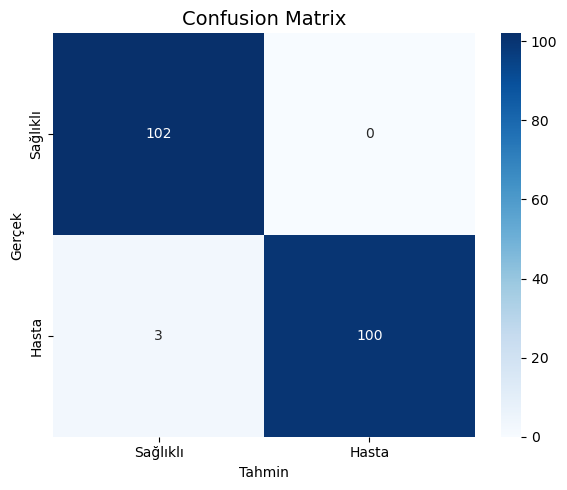

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Doğruluk oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluğu: %{accuracy*100:.2f}")

# Detaylı rapor
print("\nDetaylı Rapor:")
print(classification_report(y_test, y_pred, target_names=["Sağlıklı", "Hasta"]))

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sağlıklı", "Hasta"],
            yticklabels=["Sağlıklı", "Hasta"])
plt.title("Confusion Matrix", fontsize=14)
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.tight_layout()
plt.show()

C:\Users\yusuf\AppData\Local\Temp\ipykernel_17524\3736038914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=onem, x="Önem", y="Özellik", palette="Blues_r")


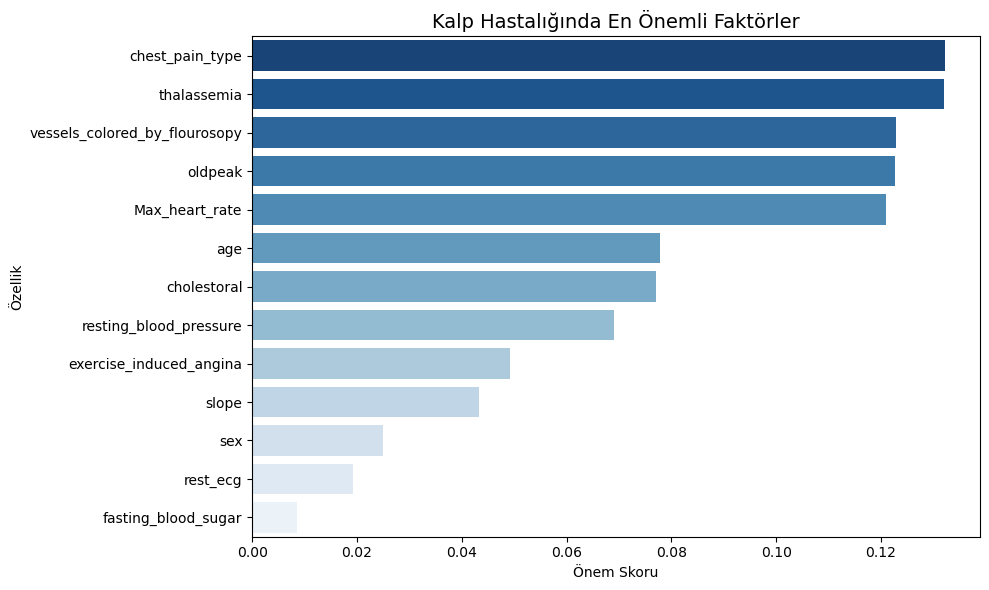

                          Özellik      Önem
2                 chest_pain_type  0.132266
12                    thalassemia  0.132048
11  vessels_colored_by_flourosopy  0.122825
9                         oldpeak  0.122702
7                  Max_heart_rate  0.120991
0                             age  0.077909
4                     cholestoral  0.077015
3          resting_blood_pressure  0.069030
8         exercise_induced_angina  0.049155
10                          slope  0.043238
1                             sex  0.025040
6                        rest_ecg  0.019163
5             fasting_blood_sugar  0.008617


In [18]:
# Özelliklerin önem sırası
onem = pd.DataFrame({
    "Özellik": X.columns,
    "Önem": model.feature_importances_
}).sort_values("Önem", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=onem, x="Önem", y="Özellik", palette="Blues_r")
plt.title("Kalp Hastalığında En Önemli Faktörler", fontsize=14)
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.show()

print(onem)

In [19]:
readme = """# 🏥 Kalp Hastalığı Tahmini — Machine Learning

## 📌 Proje Hakkında
UCI Heart Disease veri seti kullanılarak kalp hastası olup olmadığını tahmin eden bir makine öğrenmesi modeli geliştirilmiştir.

## 📊 Veri Seti
- 1025 hasta kaydı, 13 özellik
- Kaynak: Kaggle — Heart Disease UCI Dataset

## 🤖 Model
- Algoritma: Random Forest Classifier (100 ağaç)
- Doğruluk: %98.54
- Test seti: 205 hasta

## 🔍 En Önemli Faktörler
1. Göğüs ağrısı tipi (chest_pain_type)
2. Talasemi (thalassemia)
3. Boyanan damar sayısı (vessels_colored_by_flourosopy)
4. ST depresyonu (oldpeak)
5. Maksimum kalp hızı (Max_heart_rate)

## 🔧 Kullanılan Teknolojiler
- Python 3
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn (RandomForestClassifier)

## 🚀 Nasıl Çalıştırılır?
```bash
pip install pandas numpy matplotlib seaborn scikit-learn jupyter
jupyter notebook kalp_hastaligi.ipynb
```
"""

with open("README_kalp.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README oluşturuldu!")

README oluşturuldu!
